In [1]:
import pandas as pd
import numpy as np

In [2]:
sms = pd.read_csv("Dataset\spam.csv", encoding="latin-1")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\devan\AppData\Local\Temp\ipykernel_22600\2162528744.py:1: SyntaxWarning: invalid escape sequence '\s'
  sms = pd.read_csv("Dataset\spam.csv", encoding="latin-1")


In [3]:
sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
sms.shape

(5572, 5)

In [5]:
# steps to make a project

# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [6]:
sms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# drop last 3 columns

sms.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

In [8]:
sms

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
# rename the columns

sms.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [11]:
sms['target'] = encoder.fit_transform(sms['target'])

In [12]:
sms.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# missing values

sms.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
# check for duplicate value

sms.duplicated().sum()

np.int64(403)

In [15]:
# remove duplicates

sms = sms.drop_duplicates(keep='first')


In [16]:
sms.duplicated().sum()

np.int64(0)

In [17]:
sms.shape

(5169, 2)

## 2. EDA

In [18]:
sms.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
sms['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

In [20]:
import matplotlib.pyplot as plt

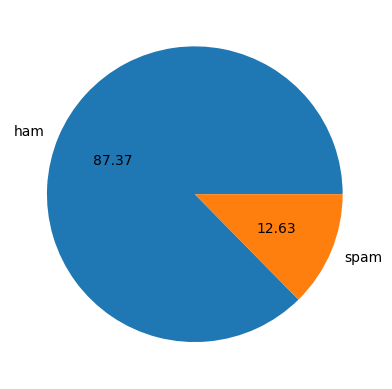

In [21]:
plt.pie(sms['target'].value_counts(), labels = ['ham', 'spam'], autopct = "%0.2f")
plt.show()

In [22]:
# data is imbalanced

In [23]:
import nltk

In [24]:
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [25]:
sms['num_char'] = sms['text'].apply(len)

C:\Users\devan\AppData\Local\Temp\ipykernel_22600\3458224215.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sms['num_char'] = sms['text'].apply(len)


In [26]:
# num of words

sms['num_words'] = sms['text'].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\devan\AppData\Local\Temp\ipykernel_22600\3193653685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sms['num_words'] = sms['text'].apply(lambda x:len(nltk.word_tokenize(x)))


In [27]:
sms['num_sentence'] = sms['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\devan\AppData\Local\Temp\ipykernel_22600\2516479364.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sms['num_sentence'] = sms['text'].apply(lambda x:len(nltk.sent_tokenize(x)))


In [28]:
sms

,target,text,num_char,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [29]:
sms[['num_char', 'num_words', 'num_sentence']].describe()

,num_char,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
sms[sms['target'] == 0][['num_char','num_words','num_sentence']].describe()

,num_char,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
sms[sms['target'] == 1][['num_char', 'num_words', 'num_sentence']].describe()

,num_char,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [32]:
import seaborn as sns

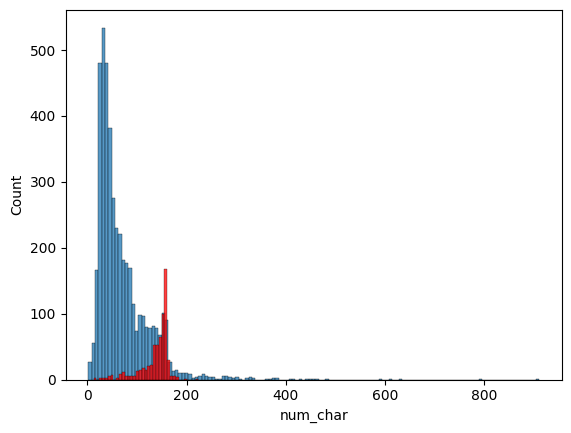

In [36]:
sns.histplot(sms[sms['target'] == 0]['num_char'])
sns.histplot(sms[sms['target'] == 1]['num_char'], color='red')
plt.show()

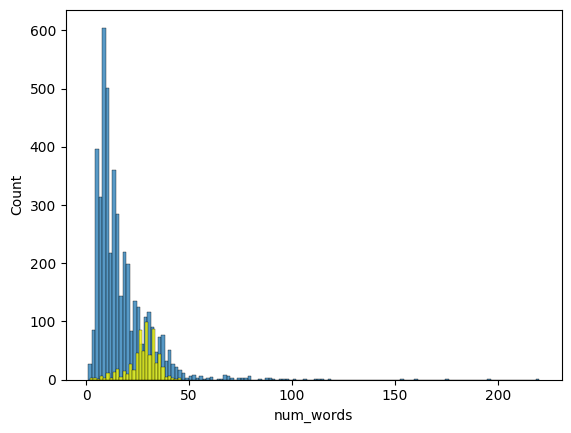

In [40]:
sns.histplot(sms[sms['target'] == 0]['num_words'])
sns.histplot(sms[sms['target'] == 1]['num_words'], color='yellow')
plt.show()

<Axes: xlabel='num_sentence', ylabel='Count'>

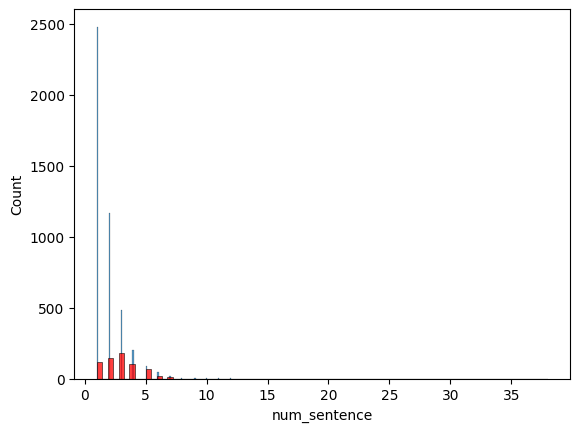

In [42]:
sns.histplot(sms[sms['target'] == 0]['num_sentence'])
sns.histplot(sms[sms['target'] == 1]['num_sentence'], color = 'red')

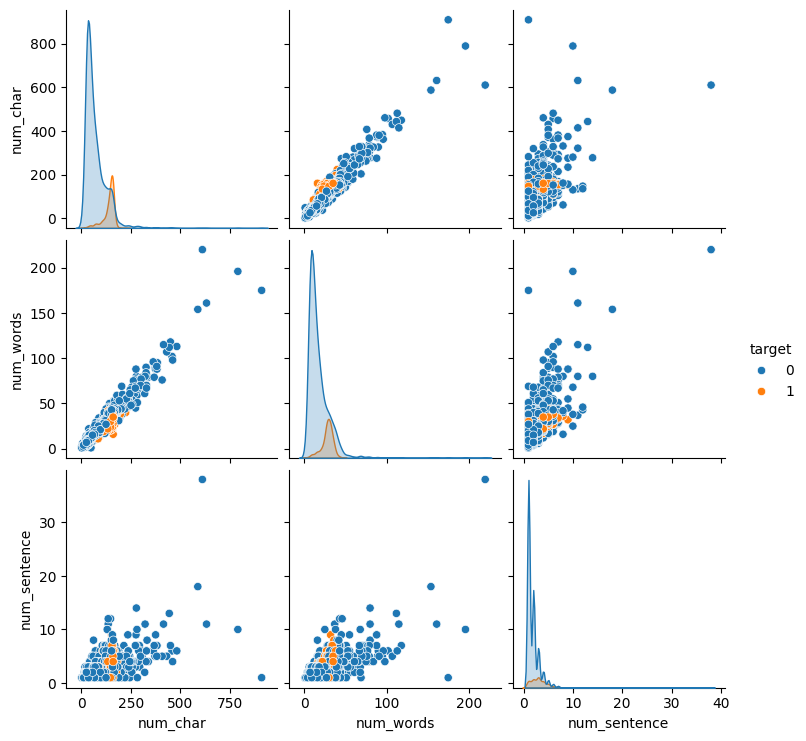

In [43]:
sns.pairplot(sms, hue='target')

<Axes: >

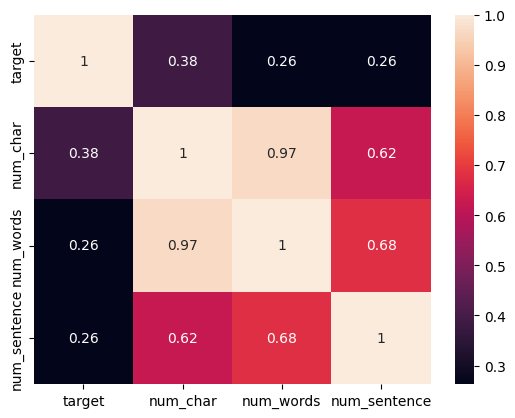

In [49]:
sns.heatmap(sms.corr(numeric_only=True), annot=True)

## 3. Text Preprocessing

- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [74]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [75]:
from nltk.corpus import stopwords

In [65]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [72]:
transform_text("Did you like my presentation on ML?")

['like', 'presentation', 'ml']

In [73]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [77]:
transform_text('I loved the YT lectures on machine learning. How about you?')

'love yt lectur machin learn'

In [78]:
sms['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [ ]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...') 

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [82]:
sms['transformed_text'] = sms['text'].apply(transform_text)

C:\Users\devan\AppData\Local\Temp\ipykernel_22600\860222750.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sms['transformed_text'] = sms['text'].apply(transform_text)


In [83]:
sms.head()

,target,text,num_char,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [95]:
from wordcloud import WordCloud
wc = WordCloud(width = 500, height=500, min_font_size = 10, background_color='white')

In [96]:
spam_wc = wc.generate(sms[sms['target'] == 1]['transformed_text'].str.cat(sep = " "))

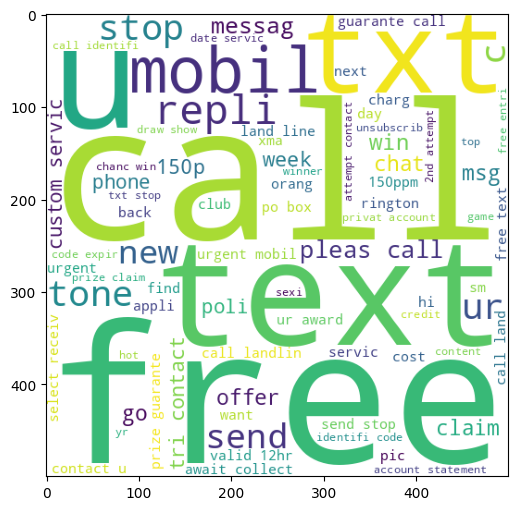

In [100]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [102]:
ham_wc = wc.generate(sms[sms['target'] == 0]['transformed_text'].str.cat(sep = " "))

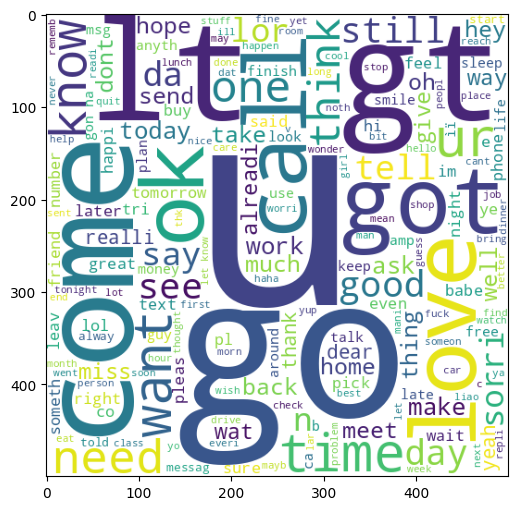

In [103]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [105]:
sms.head()

,target,text,num_char,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [108]:
spam_corpus = []
for msg in sms[sms['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [110]:
len(spam_corpus)

9939

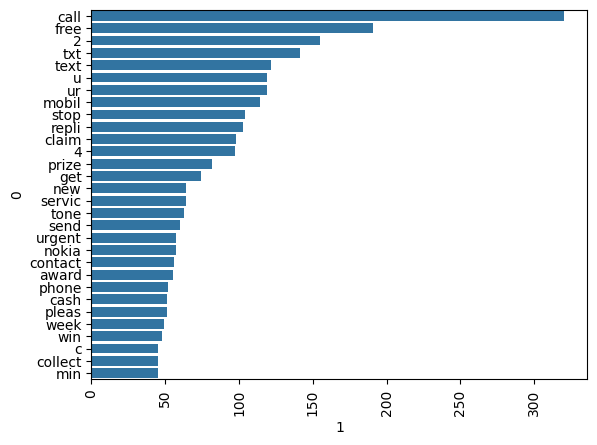

In [119]:
from collections import Counter

df = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=df[1], y=df[0])
plt.xticks(rotation = 'vertical')
plt.show()

In [122]:
ham_corpus = []
for msg in sms[sms['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [123]:
len(ham_corpus)

35404

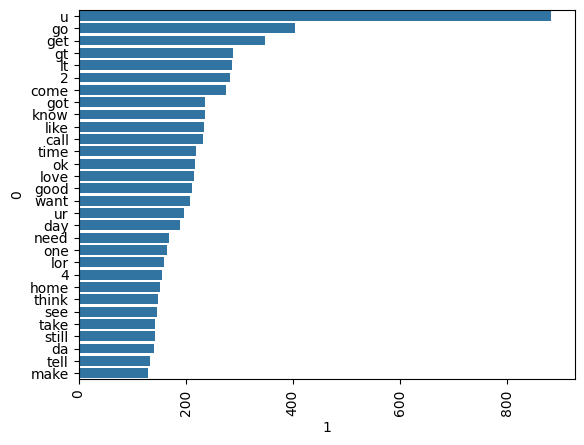

In [124]:
df = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=df[1], y=df[0])
plt.xticks(rotation = 'vertical')
plt.show()

## 4. Model Building

In [127]:
sms.head()

,target,text,num_char,num_words,num_sentence,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [142]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [129]:
x = cv.fit_transform(sms['transformed_text']).toarray()

In [132]:
x.shape

(5169, 6708)

In [133]:
y = sms['target'].values

In [134]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [135]:
from sklearn.model_selection import train_test_split

In [211]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [212]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [213]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [214]:
gnb.fit(x_train, y_train)
y_pred_gnb = gnb.predict(x_test)
print(accuracy_score(y_test, y_pred_gnb))
print(confusion_matrix(y_test, y_pred_gnb))
print(precision_score(y_test, y_pred_gnb))

0.8762088974854932
[[784 112]
 [ 16 122]]
0.5213675213675214


In [215]:
mnb.fit(x_train, y_train)
y_pred_mnb = mnb.predict(x_test)
print(accuracy_score(y_test, y_pred_mnb))
print(confusion_matrix(y_test, y_pred_mnb))
print(precision_score(y_test, y_pred_mnb))

0.9787234042553191
[[889   7]
 [ 15 123]]
0.9461538461538461


In [216]:
bnb.fit(x_train, y_train)
y_pred_bnb = bnb.predict(x_test)
print(accuracy_score(y_test, y_pred_bnb))
print(confusion_matrix(y_test, y_pred_bnb))
print(precision_score(y_test, y_pred_bnb))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [239]:
# using Tfidf vectorization

x = tfidf.fit_transform(sms['transformed_text']).toarray()

In [240]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [209]:
gnb.fit(x_train, y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.874274661508704
[[790 106]
 [ 24 114]]
0.5181818181818182


In [241]:
mnb.fit(x_train, y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [192]:
bnb.fit(x_train, y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [149]:
# tfidf -> MNB

In [150]:
# comparing multinomial naive bayes to other machine learning models

In [193]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble  import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [217]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators = 50, random_state = 2)

In [218]:
clfs = {
    'SVC': svc,
    'KN': knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC' : bc,
    'ETC' : etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [219]:
def train_classifier(clf, x_train, x_test, y_train, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy,precision

In [220]:
accuracy_list = []
precision_list = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, x_train, x_test, y_train, y_test)

    print(name)
    print("Accuracy", current_accuracy)
    print("Precision", current_precision)

    accuracy_list.append(current_accuracy)
    precision_list.append(current_precision)

SVC
Accuracy 0.9700193423597679
Precision 0.9421487603305785
KN
Accuracy 0.9052224371373307
Precision 0.9761904761904762
NB
Accuracy 0.9787234042553191
Precision 0.9461538461538461
DT
Accuracy 0.9323017408123792
Precision 0.8333333333333334
LR
Accuracy 0.9671179883945842
Precision 0.9642857142857143
RF
Accuracy 0.9738878143133463
Precision 0.9826086956521739
AdaBoost
Accuracy 0.9216634429400387
Precision 0.8202247191011236
BgC
Accuracy 0.9584139264990329
Precision 0.8682170542635659
ETC
Accuracy 0.9748549323017408
Precision 0.9745762711864406
GBDT
Accuracy 0.9506769825918762
Precision 0.9306930693069307
xgb
Accuracy 0.9680851063829787
Precision 0.9487179487179487


In [182]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(), 'Accurecy': accuracy_list, 'precision': precision_list})

In [198]:
performance_df['Accuracy_max_3000'] = accuracy_list
performance_df['Precision_max_3000'] = precision_list

In [221]:
performance_df['Accuracy_Scaling'] = accuracy_list
performance_df['Precision_Scaling'] = precision_list

In [186]:
performance_df.sort_values(by='precision', ascending=False).reset_index(drop=True)

,Algorithm,Accurecy,precision
0,KN,0.900387,1.000000
1,NB,0.959381,1.000000
2,RF,0.971954,1.000000
3,ETC,0.972921,0.982456
4,SVC,0.972921,0.974138
5,xgb,0.974855,0.951613
6,LR,0.951644,0.940000
7,GBDT,0.952611,0.923810
8,BgC,0.958414,0.862595
9,AdaBoost,0.924565,0.840909


In [ ]:
# model improvement
# 1. change the max_features parameter of TfIdf

In [238]:
tfidf = TfidfVectorizer(max_features=3000)

In [222]:
performance_df

,Algorithm,Accurecy,precision,Accuracy_max_3000,Precision_max_3000,Accuracy_Scaling,Precision_Scaling
0,SVC,0.972921,0.974138,0.975822,0.974790,0.970019,0.942149
1,KN,0.900387,1.000000,0.905222,1.000000,0.905222,0.976190
2,NB,0.959381,1.000000,0.970986,1.000000,0.978723,0.946154
3,DT,0.935203,0.838095,0.932302,0.833333,0.932302,0.833333
4,LR,0.951644,0.940000,0.955513,0.960000,0.967118,0.964286
5,RF,0.971954,1.000000,0.973888,0.982609,0.973888,0.982609
6,AdaBoost,0.924565,0.840909,0.921663,0.820225,0.921663,0.820225
7,BgC,0.958414,0.862595,0.958414,0.868217,0.958414,0.868217
8,ETC,0.972921,0.982456,0.974855,0.974576,0.974855,0.974576
9,GBDT,0.952611,0.923810,0.950677,0.930693,0.950677,0.930693


In [210]:
# scaling x

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x = scaler.fit_transform(x)

In [226]:
# appending the num_char column to x

x = np.hstack((x, sms['num_char'].values.reshape(-1,1)))

In [227]:
x.shape

(5169, 3001)

In [228]:
# voting classifier

svc = SVC(kernel='sigmoid', gamma = 1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [232]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting = 'soft')

voting.fit(x_train, y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [233]:
y_pred = voting.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.9796905222437138
0.9834710743801653


In [234]:
# applying stacking

estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator = RandomForestClassifier()

In [235]:
from sklearn.ensemble import StackingClassifier

In [236]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [237]:
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))

0.9796905222437138
0.9465648854961832


In [242]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))